In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import pandas as pd
import time

# Setting device for training
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: mps


In [2]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False,
    num_workers=0
)

print("Training images:", len(train_dataset))
print("Testing images:", len(test_dataset))
print("Classes:", train_dataset.classes)

100.0%


Training images: 50000
Testing images: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [3]:
def train_model(model, train_loader, epochs, learning_rate):
    criterion = nn.CrossEntropyLoss()

    optimizer = optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=learning_rate
    )

    losses = []

    start_time = time.time()

    for epoch in range(epochs):
        model.train()

        running_loss = 0.0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            running_loss += loss.item()

        epoch_loss = running_loss / len(train_loader)
        losses.append(epoch_loss)

        print(
            f"Epoch {epoch + 1}/{epochs}, "
            f"Loss: {epoch_loss:.4f}"
        )

    training_time = time.time() - start_time

    return losses, training_time

In [4]:
def evaluate_model(model, test_loader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total

    return accuracy

In [5]:
model_frozen = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

# Freeze all pretrained layers
for param in model_frozen.parameters():
    param.requires_grad = False

# Replace final classifier for CIFAR-10
num_features = model_frozen.fc.in_features

model_frozen.fc = nn.Linear(
    num_features,
    10
)

model_frozen = model_frozen.to(device)

# Count trainable parameters
trainable_params_frozen = sum(
    p.numel()
    for p in model_frozen.parameters()
    if p.requires_grad
)

print("Experiment A: Frozen Features")
print("Trainable parameters:", trainable_params_frozen)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/sunamikakarki/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100.0%


Experiment A: Frozen Features
Trainable parameters: 5130


In [6]:
epochs = 5

loss_frozen, time_frozen = train_model(
    model_frozen,
    train_loader,
    epochs=epochs,
    learning_rate=0.001
)

Epoch 1/5, Loss: 0.8260
Epoch 2/5, Loss: 0.6145
Epoch 3/5, Loss: 0.5891
Epoch 4/5, Loss: 0.5809
Epoch 5/5, Loss: 0.5673


In [7]:
accuracy_frozen = evaluate_model(
    model_frozen,
    test_loader
)

print("\nExperiment A Results")
print("--------------------")
print("Trainable Parameters:", trainable_params_frozen)
print(f"Training Time: {time_frozen:.2f} seconds")
print(f"Test Accuracy: {accuracy_frozen:.2f}%")


Experiment A Results
--------------------
Trainable Parameters: 5130
Training Time: 679.71 seconds
Test Accuracy: 80.67%


In [8]:
model_finetune = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

# First freeze everything
for param in model_finetune.parameters():
    param.requires_grad = False

# Unfreeze the final convolutional block
for param in model_finetune.layer4.parameters():
    param.requires_grad = True

# Replace final classifier
num_features = model_finetune.fc.in_features

model_finetune.fc = nn.Linear(
    num_features,
    10
)

model_finetune = model_finetune.to(device)

# Count trainable parameters
trainable_params_finetune = sum(
    p.numel()
    for p in model_finetune.parameters()
    if p.requires_grad
)

print("Experiment B: Fine-Tuning")
print("Trainable parameters:", trainable_params_finetune)

Experiment B: Fine-Tuning
Trainable parameters: 8398858


In [9]:
loss_finetune, time_finetune = train_model(
    model_finetune,
    train_loader,
    epochs=epochs,
    learning_rate=0.0001
)


Epoch 1/5, Loss: 0.4240
Epoch 2/5, Loss: 0.1391
Epoch 3/5, Loss: 0.0445
Epoch 4/5, Loss: 0.0174
Epoch 5/5, Loss: 0.0179


In [10]:
accuracy_finetune = evaluate_model(
    model_finetune,
    test_loader
)

print("\nExperiment B Results")
print("--------------------")
print("Trainable Parameters:", trainable_params_finetune)
print(f"Training Time: {time_finetune:.2f} seconds")
print(f"Test Accuracy: {accuracy_finetune:.2f}%")


Experiment B Results
--------------------
Trainable Parameters: 8398858
Training Time: 2747.54 seconds
Test Accuracy: 90.67%


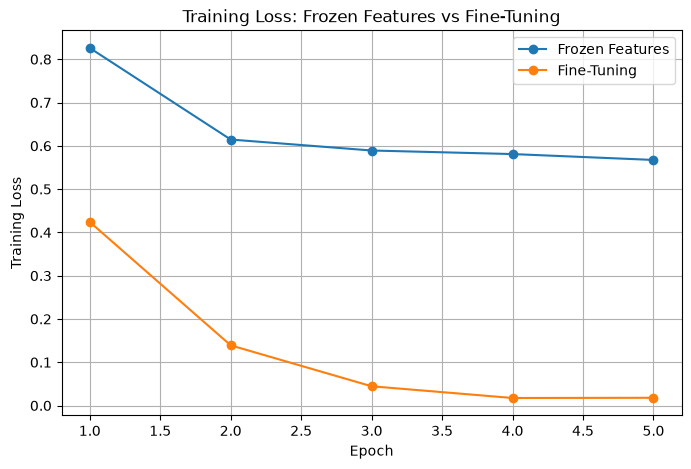

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, epochs + 1),
    loss_frozen,
    marker="o",
    label="Frozen Features"
)

plt.plot(
    range(1, epochs + 1),
    loss_finetune,
    marker="o",
    label="Fine-Tuning"
)

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Training Loss: Frozen Features vs Fine-Tuning")
plt.legend()
plt.grid(True)

plt.show()

In [12]:
results = pd.DataFrame({
    "Method": [
        "Frozen Features",
        "Fine-Tuning"
    ],

    "Trainable Parameters": [
        trainable_params_frozen,
        trainable_params_finetune
    ],

    "Training Time (seconds)": [
        round(time_frozen, 2),
        round(time_finetune, 2)
    ],

    "Accuracy (%)": [
        round(accuracy_frozen, 2),
        round(accuracy_finetune, 2)
    ]
})

print(results.to_string(index=False))

         Method  Trainable Parameters  Training Time (seconds)  Accuracy (%)
Frozen Features                  5130                   679.71         80.67
    Fine-Tuning               8398858                  2747.54         90.67


In [13]:
print("=" * 60)
print("TRANSFER LEARNING EXPERIMENT RESULTS")
print("=" * 60)

print("\nExperiment A - Frozen Features")
print("Trainable Parameters:", trainable_params_frozen)
print(f"Training Time: {time_frozen:.2f} seconds")
print(f"Test Accuracy: {accuracy_frozen:.2f}%")

print("\nExperiment B - Fine-Tuning")
print("Trainable Parameters:", trainable_params_finetune)
print(f"Training Time: {time_finetune:.2f} seconds")
print(f"Test Accuracy: {accuracy_finetune:.2f}%")

print("\nComparison Table:")
print(results.to_string(index=False))

TRANSFER LEARNING EXPERIMENT RESULTS

Experiment A - Frozen Features
Trainable Parameters: 5130
Training Time: 679.71 seconds
Test Accuracy: 80.67%

Experiment B - Fine-Tuning
Trainable Parameters: 8398858
Training Time: 2747.54 seconds
Test Accuracy: 90.67%

Comparison Table:
         Method  Trainable Parameters  Training Time (seconds)  Accuracy (%)
Frozen Features                  5130                   679.71         80.67
    Fine-Tuning               8398858                  2747.54         90.67


### Discussion: Frozen Feature Extraction vs. Fine-Tuning

In this experiment, I compared frozen feature extraction and fine-tuning using a pretrained ResNet18 model on the CIFAR-10 dataset. Both experiments were trained for five epochs using the same dataset. In Experiment A, only the final classification layer was trained, resulting in 5,130 trainable parameters and 80.67% test accuracy. The training time for Experiment A was 679.71 seconds. In Experiment B, the final convolutional block and classification layer were trained, resulting in 8,398,858 trainable parameters and 90.67% test accuracy. The training time for Experiment B was 2,747.54 seconds, which was longer because more parameters were updated. Fine-tuning improved the accuracy by 10 percentage points because the model could adapt its pretrained features to the CIFAR-10 dataset. Overall, fine-tuning provided better accuracy, while frozen feature extraction required less training time.